### Загрузка библиотек и данных

In [14]:
# Импортируем библиотеки
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.preprocessing import LabelEncoder

In [ ]:
# Загружаем данные для обучения в датафрейм
df_churn = pd.read_csv('data/vw_churn_data.csv')

In [37]:
df_churn.head()

,gender,age,married,state,number_of_referrals,tenure_in_months,value_deal,phone_service,multiple_lines,internet_service,...,contract,paperless_billing,payment_method,monthly_charge,total_charges,total_refunds,total_extra_data_charges,total_long_distance_charges,total_revenue,customer_status
0,1,35,0,4,7,27,5,1,0,1,...,1,1,1,65.6,593.30,0.00,0.0,381.51,974.81,0
1,0,45,1,12,14,13,5,1,1,1,...,0,0,1,-4.0,542.40,38.33,10.0,96.21,610.28,0
2,1,51,0,21,4,35,4,1,0,1,...,0,1,0,73.9,280.85,0.00,0.0,134.60,415.45,1
3,1,79,0,9,3,21,3,1,0,1,...,0,1,0,98.0,1237.85,0.00,0.0,361.66,1599.51,1
4,0,80,0,17,3,8,5,1,0,1,...,0,1,1,83.9,267.40,0.00,0.0,22.14,289.54,1


### Предобработка данных

In [33]:
# Убираем столбцы, которые не будут участвовать в обучении модели
df_churn = df_churn.drop(['customer_id', 'churn_category', 'churn_reason'], axis=1)

In [ ]:
# Список столбцов для кодировки в категоральные переменные
columns_to_encode = [
    'gender', 'married', 'state', 'value_deal', 'phone_service', 'multiple_lines',
    'internet_service', 'internet_type', 'online_security', 'online_backup',
    'device_protection_plan', 'premium_support', 'streaming_tv', 'streaming_movies',
    'streaming_music', 'unlimited_data', 'contract', 'paperless_billing',
    'payment_method'
]

# Кодируем категоральные переменные
label_encoders = {}

for column in columns_to_encode:
    label_encoders[column] = LabelEncoder()
    df_churn[column] = label_encoders[column].fit_transform(df_churn[column])

# Вручную кодируем столбец со статусом клиента ('customer_status') на 0 (остался) и 1 (ушёл)
df_churn['customer_status'] = df_churn['customer_status'].map({'Stayed': 0, 'Churned': 1})

# Разделяем данные на признаки (X) и ответы к ним (y)
X = df_churn.drop('customer_status', axis = 1)
y = df_churn['customer_status']

# Разделяем данные на учебную и проверочную выборки
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
# test_size=0.2 означает, что проверочная выборка будет составлять 20% от данных, а 80% - учебная
# random_state=42 обеспечит стабильность отбора при повторном вызове функции

In [35]:
df_churn['customer_status']

0       0
1       0
2       1
3       1
4       1
       ..
6002    1
6003    0
6004    1
6005    0
6006    0
Name: customer_status, Length: 6007, dtype: int64

### Тренировка модели по классификатору случайного леса (Random forest)

Confusion Matrix:
[[790  47]
 [153 212]]

Classification Report:
              precision    recall  f1-score   support

           0       0.84      0.94      0.89       837
           1       0.82      0.58      0.68       365

    accuracy                           0.83      1202
   macro avg       0.83      0.76      0.78      1202
weighted avg       0.83      0.83      0.82      1202



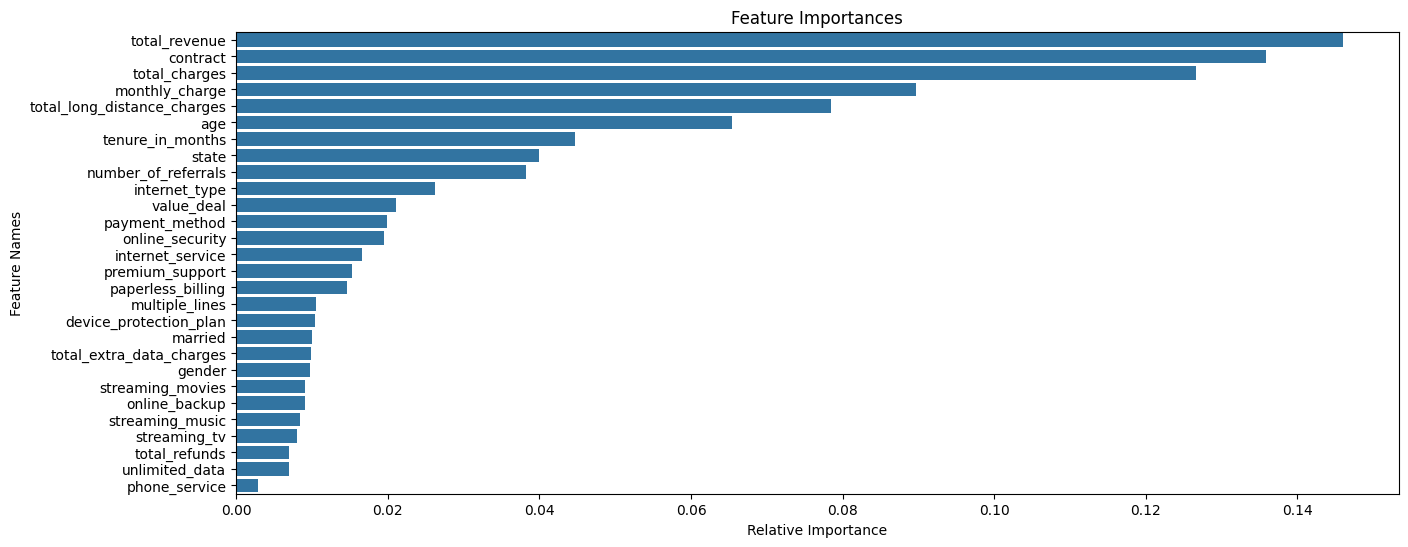

In [36]:
# Подключаем классификатор случайного леса
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)

# Обучаем модель
rf_model.fit(X_train, y_train)

# Создаём прогноз
y_pred = rf_model.predict(X_test)

# Оцениваем модель
print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred))
print("\nClassification Report:")
print(classification_report(y_test, y_pred))

# Добавляем веса для признаков
importances = rf_model.feature_importances_
indices = np.argsort(importances)[::-1]

# Строим график весов для признаков
plt.figure(figsize=(15, 6))
sns.barplot(x=importances[indices], y=X.columns[indices])
plt.title('Feature Importances')
plt.xlabel('Relative Importance')
plt.ylabel('Feature Names')
plt.show()

### Использование модели для прогнозирования

In [41]:
# Загружаем в отдельный датафрейм новые данные для проверки модели
df_new_data = pd.read_csv('data/vw_join_data.csv')

In [42]:
# Проверяем содержимое датафрейма
df_new_data.head()

,customer_id,gender,age,married,state,number_of_referrals,tenure_in_months,value_deal,phone_service,multiple_lines,...,payment_method,monthly_charge,total_charges,total_refunds,total_extra_data_charges,total_long_distance_charges,total_revenue,customer_status,churn_category,churn_reason
0,93520-GUJ,Female,67,No,Gujarat,13,19,Deal 5,Yes,Yes,...,Bank Withdrawal,72.10,72.1,0.0,0.0,7.77,79.87,Joined,Others,Others
1,57256-BIH,Female,18,No,Bihar,9,7,NaN,Yes,No,...,Credit Card,19.85,57.2,0.0,0.0,9.36,66.56,Joined,Others,Others
2,72357-MAD,Female,53,No,Madhya Pradesh,14,12,Deal 5,Yes,No,...,Credit Card,44.30,44.3,0.0,0.0,42.95,87.25,Joined,Others,Others
3,66612-KAR,Female,58,Yes,Karnataka,11,18,NaN,Yes,No,...,Credit Card,19.95,58.0,0.0,0.0,8.07,66.07,Joined,Others,Others
4,22119-WES,Male,31,Yes,West Bengal,5,5,NaN,Yes,No,...,Credit Card,20.05,33.7,0.0,0.0,3.62,37.32,Joined,Others,Others


In [43]:
# Создаём копию датафрейма, чтобы сохранить незакодированные столбцы
df_original_data = df_new_data.copy()

# Сохраняем ID пользователей
#customer_ids = df_new_data['customer_id']

# Убираем столбцы, которые не будут участвовать в прогнозе
df_new_data = df_new_data.drop(['customer_id', 'customer_status', 'churn_category', 'churn_reason'], axis = 1)

# Кодируем категоральные переменные
for column in df_new_data.select_dtypes(include=['object']).columns:
    df_new_data[column] = label_encoders[column].transform(df_new_data[column])

In [46]:
# Делаем прогноз
new_predictions = rf_model.predict(df_new_data)

# Добавляем столбец с результатами прогноза
df_original_data['customer_status_predicted'] = new_predictions

# Фильтруем датафрейм 
# Оставляем только потенциально уходящих пользователей (1 в кодированном виде или Churned в изначальном виде)
original_data = df_original_data[df_original_data['customer_status_predicted'] == 1]

# Сохраняем результат
original_data.to_csv('data/churn_prediction_data.csv', index = False)

Теперь вы можете вернуться в файл `2_Подробное_описание_процесса.md` и перейти к этапу визуализации в PowerBI